In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 1: Upload your CSV file

First, we'll upload your CSV file directly from your computer to this Colab environment. This uses a special function provided by Google Colab.

In [5]:
# Import the 'files' module from google.colab to handle file uploads
from google.colab import files

# This line will open a file selection dialog. Click 'Choose Files' and select your CSV.
uploaded = files.upload()

# After uploading, 'uploaded' will contain a dictionary where keys are filenames and values are the file contents.
# We'll get the name of the first (and likely only) uploaded file.
for filename in uploaded.keys():
  print(f'User uploaded file "{filename}"')
  csv_filename = filename
  break # Assuming only one file is uploaded for this example

Saving archive.zip to archive (1).zip
User uploaded file "archive (1).zip"


### Step 2: Read the CSV into a pandas DataFrame

Next, we'll use the pandas library to read the uploaded CSV file into a DataFrame. A DataFrame is like a table in a spreadsheet or a database, which is a very common way to work with data in Python.

In [6]:
# Import the pandas library, which is essential for data manipulation
import pandas as pd

# Read the uploaded CSV file into a pandas DataFrame
# The 'csv_filename' variable holds the name of the file you just uploaded
df = pd.read_csv(csv_filename)

# Display the first 5 rows of the DataFrame to check if it loaded correctly
# This helps you see what your data looks like and verify column names
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Step 3: Create a Bar Chart using Matplotlib

Now, we'll use the matplotlib library to create a bar chart. Bar charts are great for comparing categorical data. You'll need to decide which columns from your DataFrame you want to plot on the x-axis (categories) and y-axis (values).

**Important:** Replace `'Your_Category_Column'` and `'Your_Value_Column'` with actual column names from your uploaded CSV. You can see your column names in the output of the `df.head()` command above.

In [ ]:
# Import the matplotlib.pyplot module for plotting
import matplotlib.pyplot as plt

# --- Configuration for your bar chart ---
# Replace these with actual column names from your DataFrame
# For example, if your CSV has columns 'Product' and 'Sales', you'd use:
# category_column = 'Product'
# value_column = 'Sales'
category_column = 'Your_Category_Column' # e.g., 'Product_Name', 'City', 'Month'
value_column = 'Your_Value_Column'     # e.g., 'Sales_Amount', 'Count', 'Average_Score'

# --- Create the bar chart ---

# Set the figure size for better readability
plt.figure(figsize=(10, 6))

# Create the bar chart using the specified columns
# x=df[category_column] provides the categories for the x-axis
# y=df[value_column] provides the values for the height of each bar
plt.bar(x=df[category_column], y=df[value_column], color='skyblue')

# Add a title to the chart to describe what it's showing
plt.title(f'Bar Chart of {value_column} by {category_column}', fontsize=16)

# Label the x-axis clearly so viewers know what the bars represent
plt.xlabel(category_column, fontsize=12)

# Label the y-axis clearly to indicate what the height of the bars signifies
plt.ylabel(value_column, fontsize=12)

# Rotate x-axis labels if they are too long to prevent overlapping
plt.xticks(rotation=45, ha='right') # 'ha=right' aligns the labels nicely

# Add a grid to the chart for easier reading of values
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure all labels and titles fit within the figure area
plt.tight_layout()

# Display the plot
plt.show()

In [7]:
# Group by Motivation Level and calculate average previous score
grouped_df = df.groupby("Motivation_Level")["Previous_Scores"].mean().reset_index()

display(grouped_df)

,Motivation_Level,Previous_Scores
0,High,75.585292
1,Low,75.200310
2,Medium,74.792898


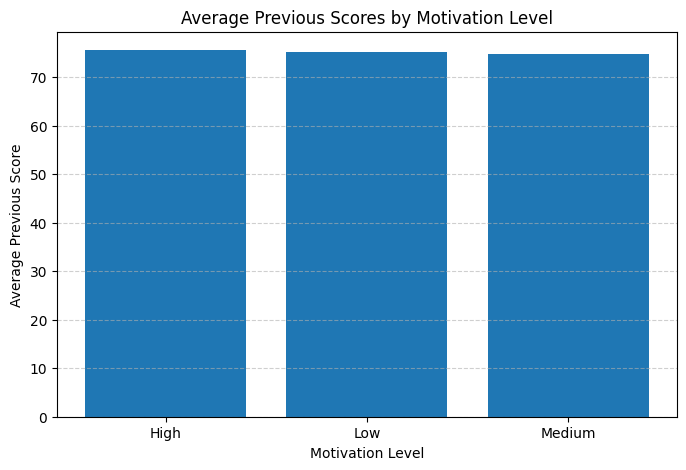

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    grouped_df["Motivation_Level"],
    grouped_df["Previous_Scores"]
)

plt.title("Average Previous Scores by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Previous Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()